## Draw the Starfield

In [4]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:70% !important; }</style>"))

### Get the Manta Sprite

In [5]:
from PIL import Image

FACTOR = 15

def get_surface_snippet(level=1, x_offset=600, y_offset = 0, width=1000, height = 200):
    img = Image.open(f"bullets_player/surface_diagrams/{level}_no_text.png")
    img = img.crop((x_offset, y_offset, x_offset + width, y_offset + height))
    #img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
    return img

def get_surface_character_snippet(level=1, x_offset=600, y_offset = 0, width=1000, height = 200):
    img = Image.open(f"surface_character_set_diagrams/surface_diagrams/{level}.png")
    img = img.crop((x_offset, y_offset, x_offset + width, y_offset + height))
    #img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
    return img

def make_shadow(img, color=(0x4a, 0x4a, 0x4a, 255)):
    d = img.getdata()
    new_image = []
    for item in d:
        if item[3] == 0:
            new_image.append(item)
        else:
            new_image.append(color)
    # update image data
    img.putdata(new_image)
    return img

resize = lambda img,factor: img.resize((int(img.width * factor), int(img.height * factor)), Image.NEAREST)
add_offset = lambda a,b : [sum(x) for x in zip(a,b)]
scale = lambda x: x * FACTOR
cells = lambda x: x * 120

In [6]:
from PIL import Image, ImageDraw

c64_to_rgb = {
"c64_black": "#000000",     
"c64_white": "#ffffff",     
"c64_red": "#813338",       
"c64_cyan":  "#75cec8",     
"c64_purple": "#8e3c97",    
"c64_green": "#56ac4d",     
"c64_blue":  "#2e2c9b",     
"c64_yellow":  "#edf171",   
"c64_orange":  "#8e5029",   
"c64_brown": "#553800",     
"c64_ltred": "#c46c71",  
"c64_gray1":  "#4a4a4a",    
"c64_lightgray": "#7b7b7b", 
"c64_ltgreen": "#a9ff9f",
"c64_ltblue":  "#706deb",
"c64_gray3": "#b2b2b2",                             
}
img = Image.open("manta_spin_diagrams/MANTA1.png")
img = resize(img, FACTOR)
manta = img.copy()
shadow = make_shadow(img)

### Get the Stars


In [38]:
small_star = Image.open("surface_characters/1_42.png")
big_star = Image.open("surface_characters/1_43.png")

### Draw The Star Background 

In [13]:
!mkdir starfield

In [63]:
c64_to_rgb = {
"c64_black": "#000000",     
"c64_white": "#ffffff",     
"c64_red": "#813338",       
"c64_cyan":  "#75cec8",     
"c64_purple": "#8e3c97",    
"c64_green": "#56ac4d",     
"c64_blue":  "#2e2c9b",     
"c64_yellow":  "#edf171",   
"c64_orange":  "#8e5029",   
"c64_brown": "#553800",     
"c64_ltred": "#c46c71",  
"c64_gray1":  "#4a4a4a",    
"c64_lightgray": "#7b7b7b", 
"c64_ltgreen": "#a9ff9f",
"c64_ltblue":  "#706deb",
"c64_gray3": "#b2b2b2",                             
}

In [52]:
import random
def addStarsToRow(background, row):
    for x in range(0,38):
        r = random.randint(0,255)
        if r < 240:
            continue
        if r < 248:
            background.paste(small_star, (cells(x), cells(row)), mask=small_star)
            continue
        background.paste(big_star, (cells(x), cells(row)), mask=big_star)
    return background

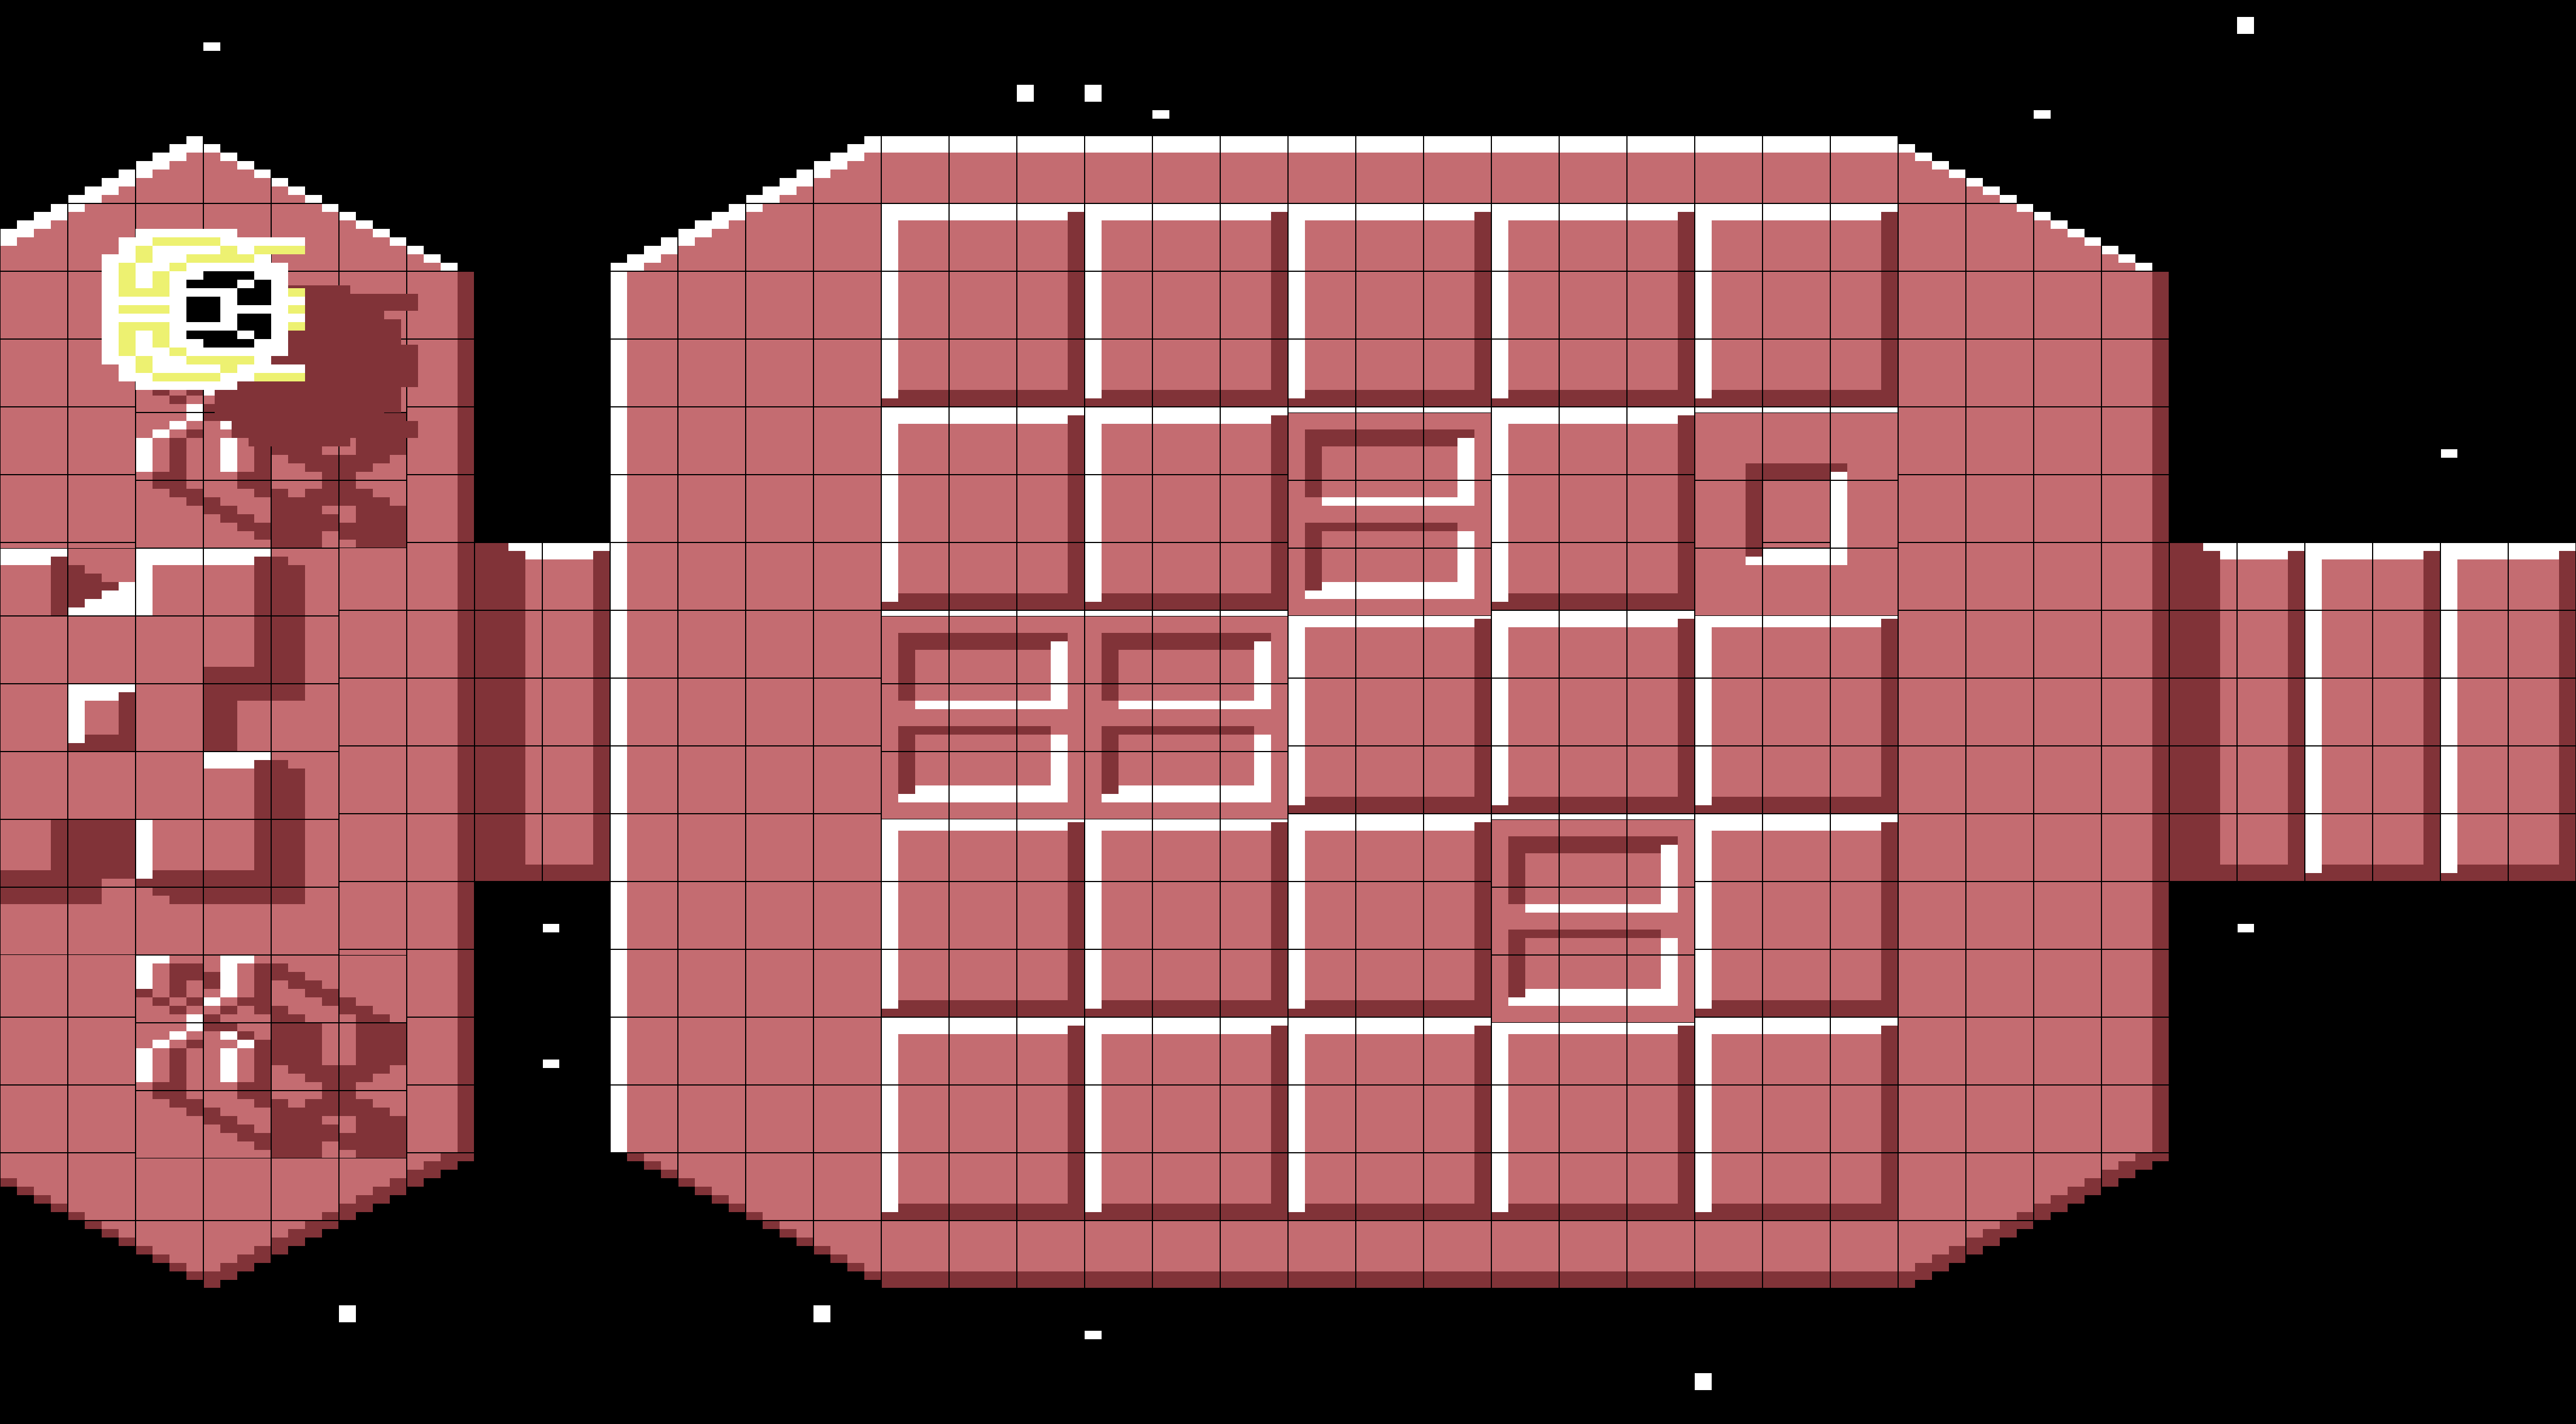

In [73]:
level = 15

background = Image.new('RGBA', (cells(38), cells(21)), color="black")

rows = [0,1,19,20,6,8,10,13,15,17,18]
for row in rows:
    background = addStarsToRow(background, row)

diagram = get_surface_snippet(level=level, x_offset=cells(65), y_offset = cells(0), width=cells(38), height = cells(17))
shadow = make_shadow(manta.copy(), color=(0x81,0x33,0x38,255))
manta_pos = (scale(12),scale(10))
shadow_offset = (20*10,10*10)
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.paste(manta, manta_pos, mask=manta)

"""
bullet_x = cells(8)
bullet_pos = (bullet_x, scale(10) + 30)
diagram.paste(bullet, bullet_pos, mask=bullet)
bullet_pos = (bullet_x, scale(25) + 30)
diagram.paste(bullet, bullet_pos, mask=bullet)
"""

background.paste(diagram, (0,cells(2)), mask=diagram)
background.save(f"starfield/dreadnought_with_stars.png")
background

### Top Stars

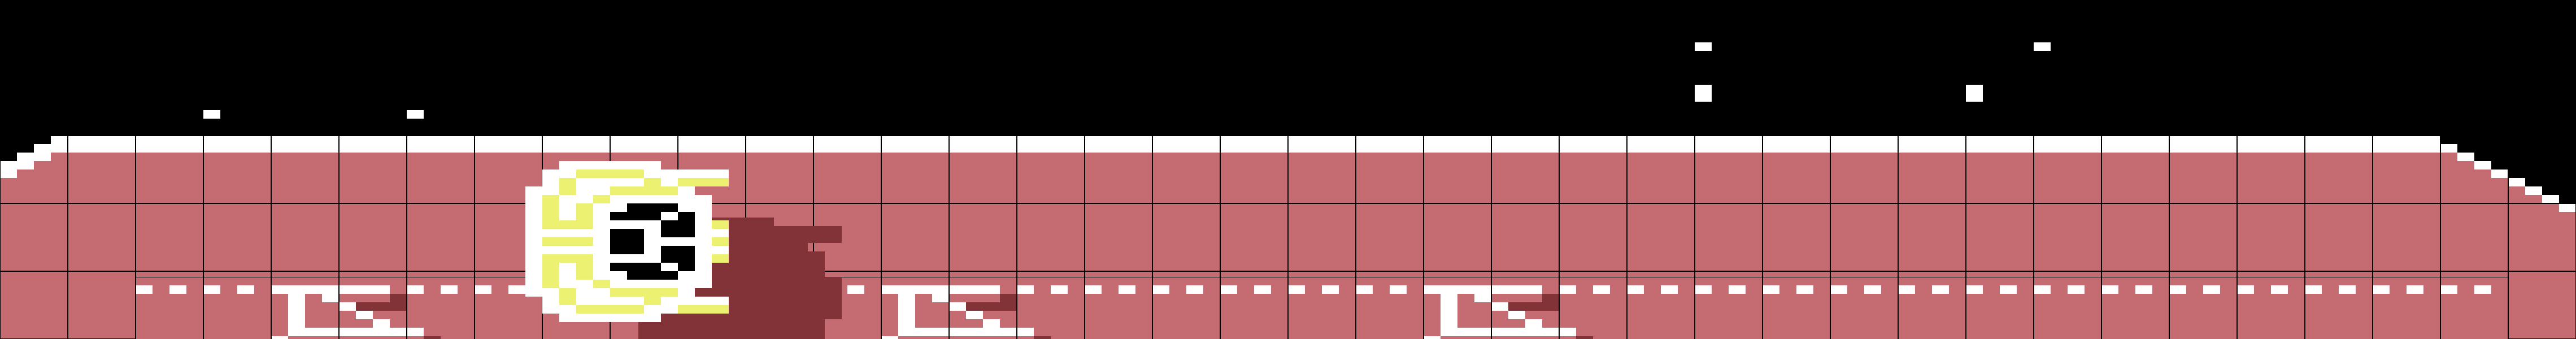

In [88]:
level = 15

background = Image.new('RGBA', (cells(38), cells(5)), color="black")

rows = [0,1,19,20,6,8,10,13,15,17,18]
for row in rows:
    background = addStarsToRow(background, row)

diagram = get_surface_snippet(level=level, x_offset=cells(110), y_offset = cells(0), width=cells(38), height = cells(3))
shadow = make_shadow(manta.copy(), color=(0x81,0x33,0x38,255))
manta_pos = (scale(62),scale(2))
shadow_offset = (20*10,10*10)
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.paste(manta, manta_pos, mask=manta)

background.paste(diagram, (0,cells(2)), mask=diagram)
background.save(f"starfield/dreadnought_with_stars_top.png")
background

### Bottom Stars

In [100]:
def make_mask(i):
    img = i.copy()
    d = img.getdata()
    new_image = []
    for item in d:
        if item[3] != 0:
            new_image.append((0xff, 0xff, 0xff))
        else:
            new_image.append((0,0,0))
    # update image data
    img.putdata(new_image)
    return img


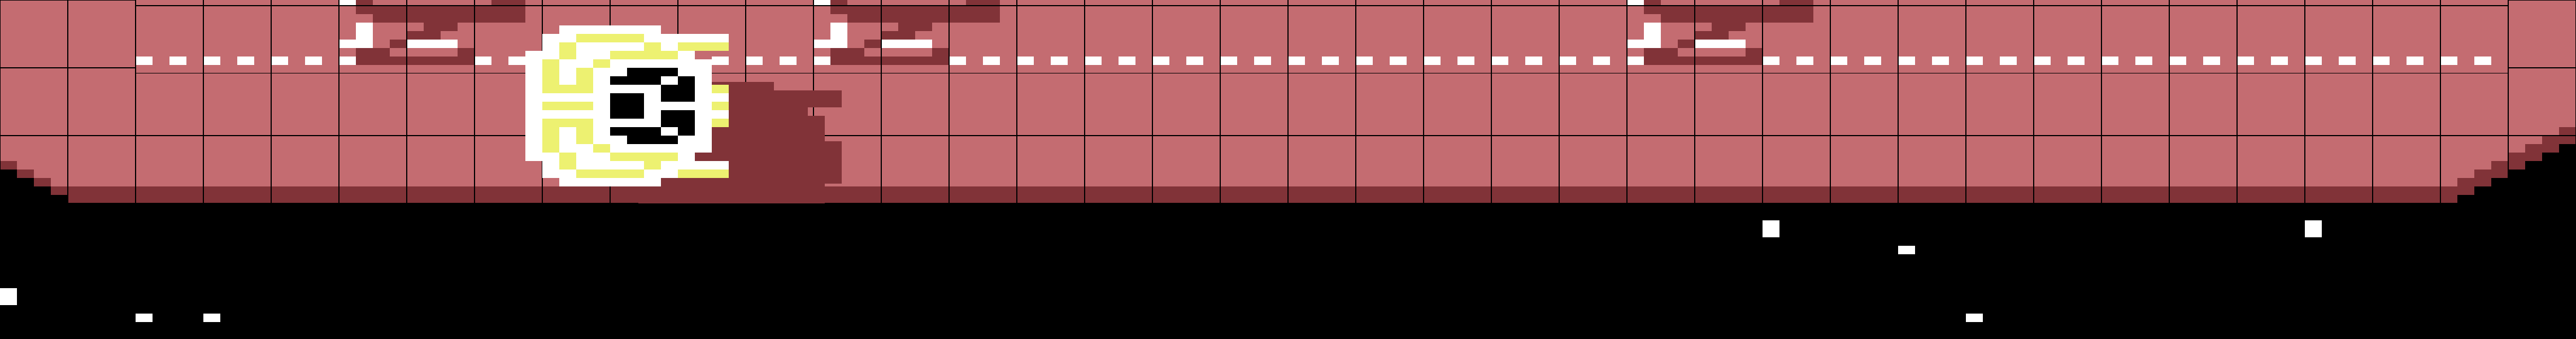

In [103]:
level = 15

background = Image.new('RGBA', (cells(38), cells(5)), color="black")

rows = [3,4]
for row in rows:
    background = addStarsToRow(background, row)

diagram = get_surface_snippet(level=level, x_offset=cells(110), y_offset = cells(14), width=cells(38), height = cells(4))
mask = make_mask(diagram).convert('L')

shadow = make_shadow(manta.copy(), color=(0x81,0x33,0x38,255))
manta_pos = (scale(62),scale(2))
shadow_offset = (20*10,10*10)
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.putalpha(mask)
diagram.paste(manta, manta_pos, mask=manta)

background.paste(diagram, (0,cells(0)), mask=diagram)
background.save(f"starfield/dreadnought_with_stars_bottom.png")
background

In [108]:
0x14

20

### Just the background

In [136]:
import random
def addRandomStar(background):
    rx = random.randint(0,31)
    if rx < 20:
        rx+=4
    ry = random.randint(7,22)
    rs = random.randint(0,1)
    background.paste(small_star if rs else big_star, (cells(rx), cells(ry)), mask=small_star if rs else big_star)
    return background

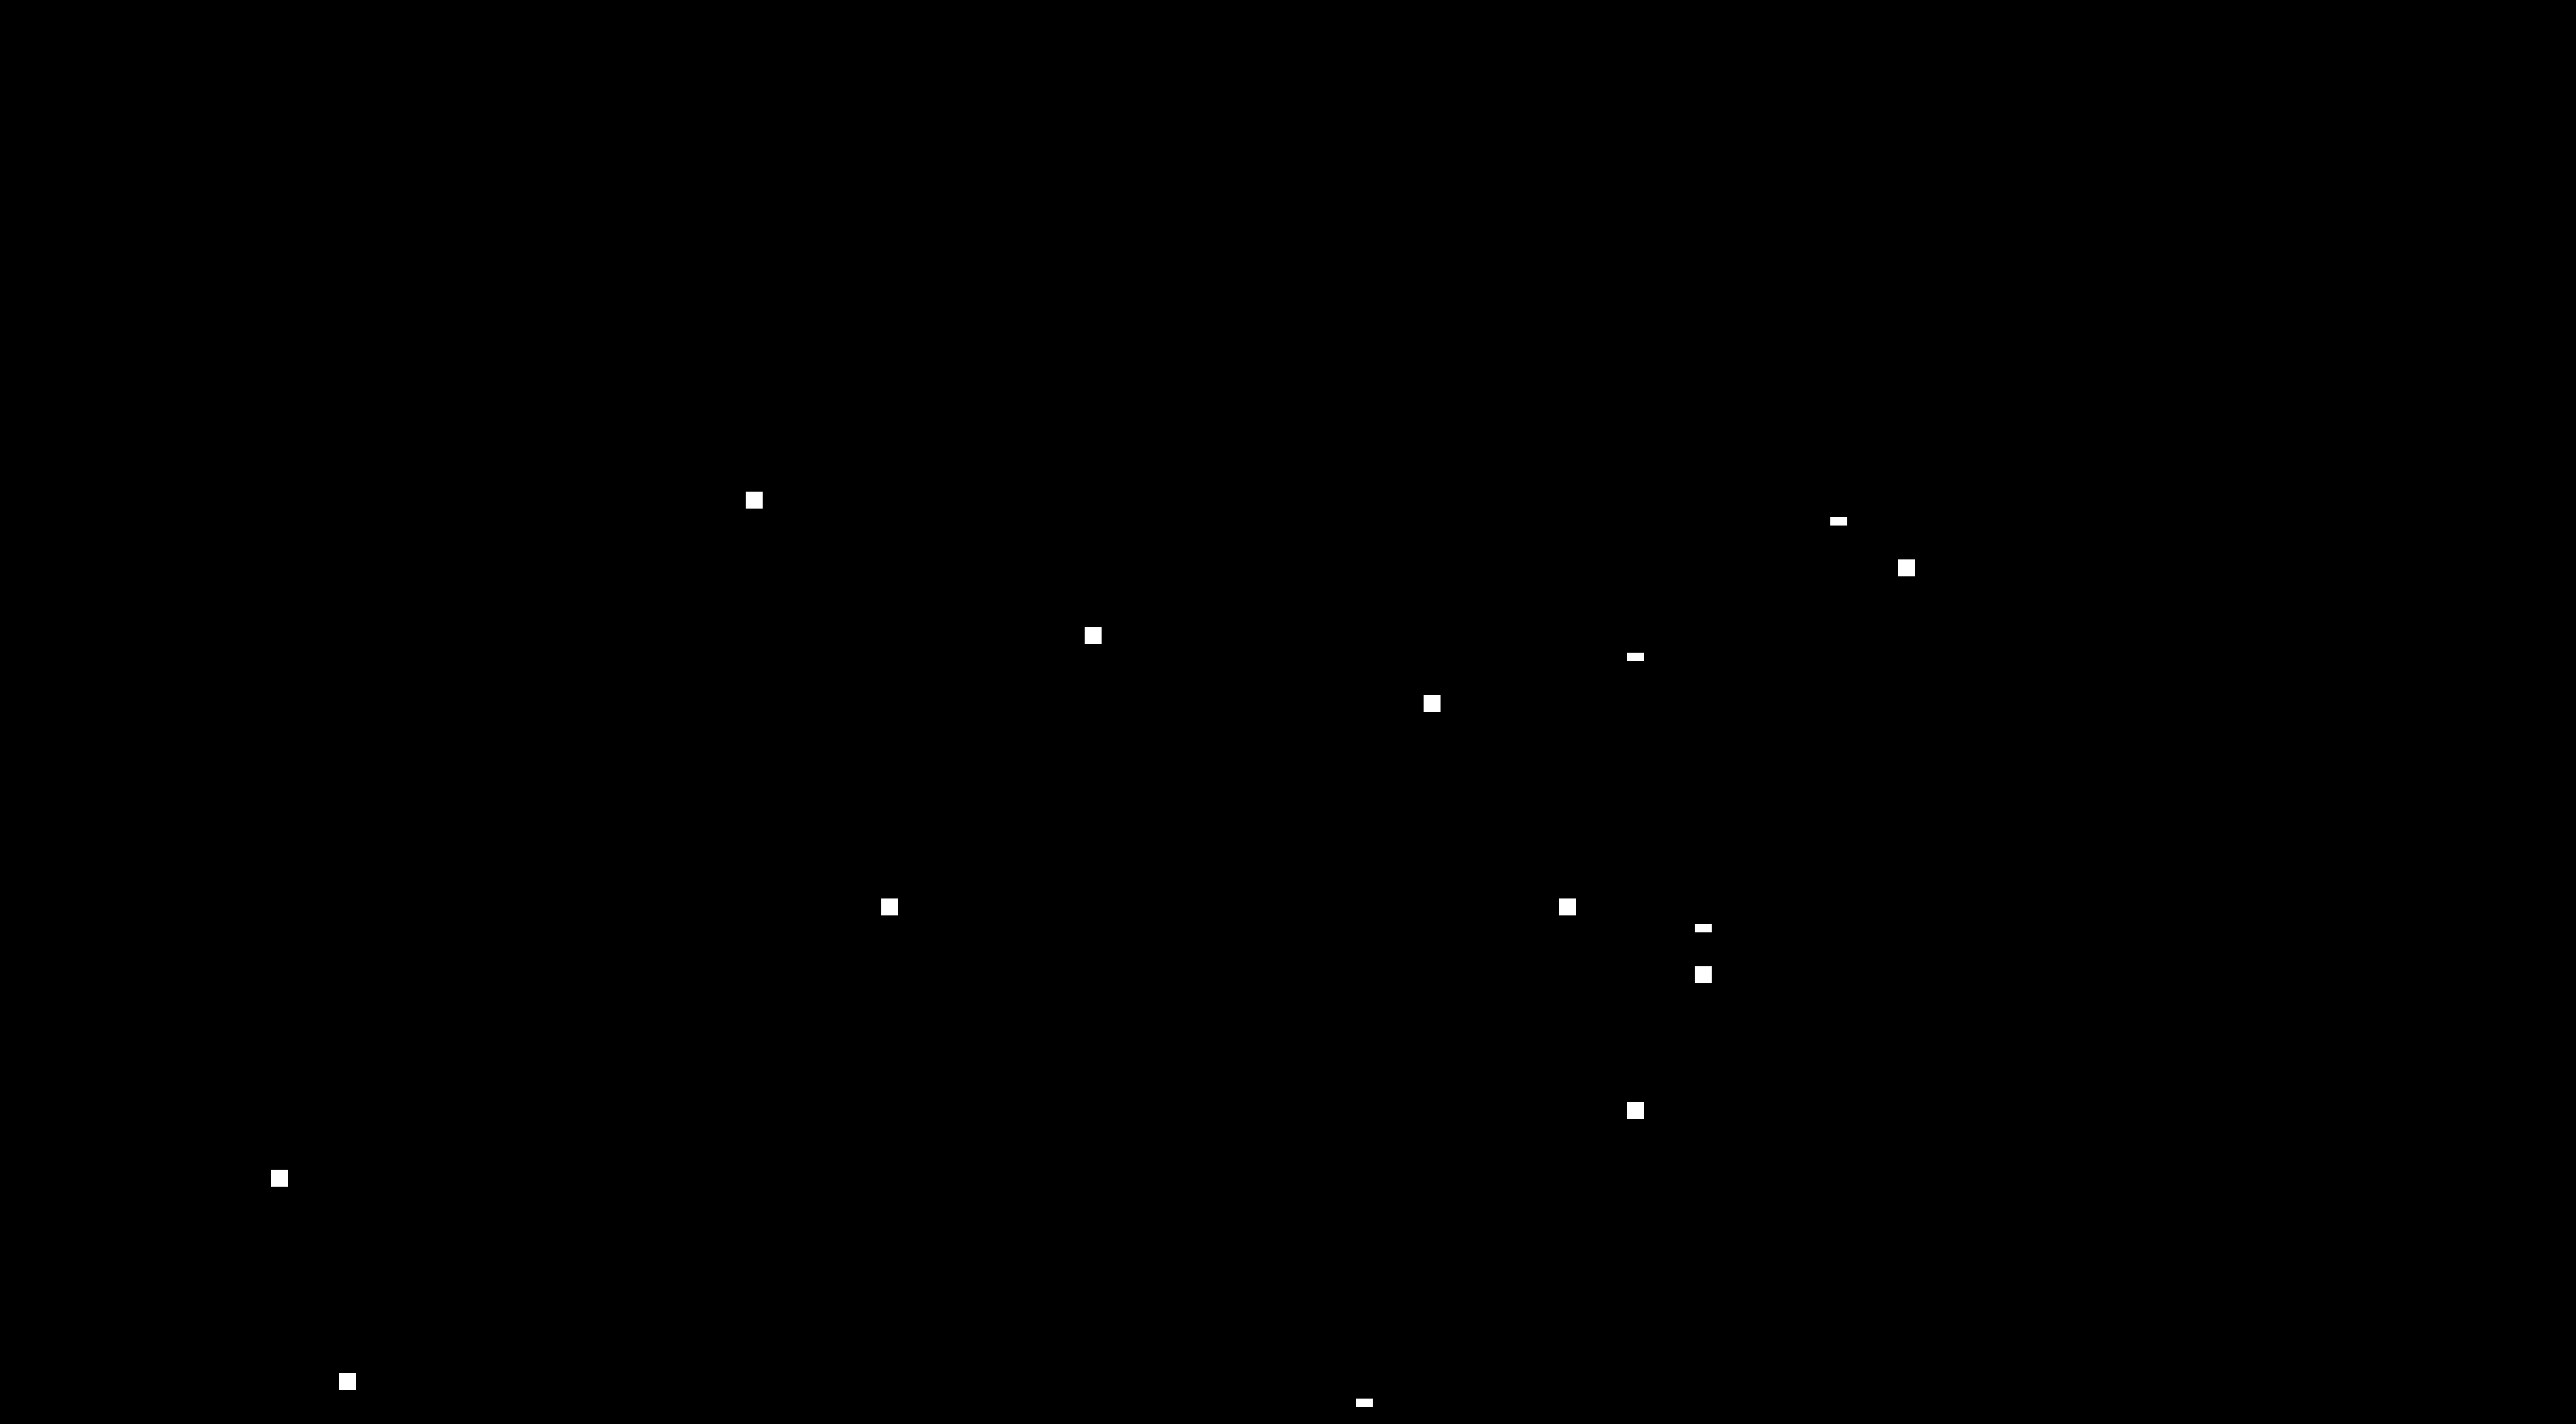

In [141]:
background = Image.new('RGBA', (cells(38), cells(21)), color="black")
for i in range(0,16):
    background = addRandomStar(background)
background.save(f"starfield/background_stars_2.png")
background

### Full Star Background Rendering

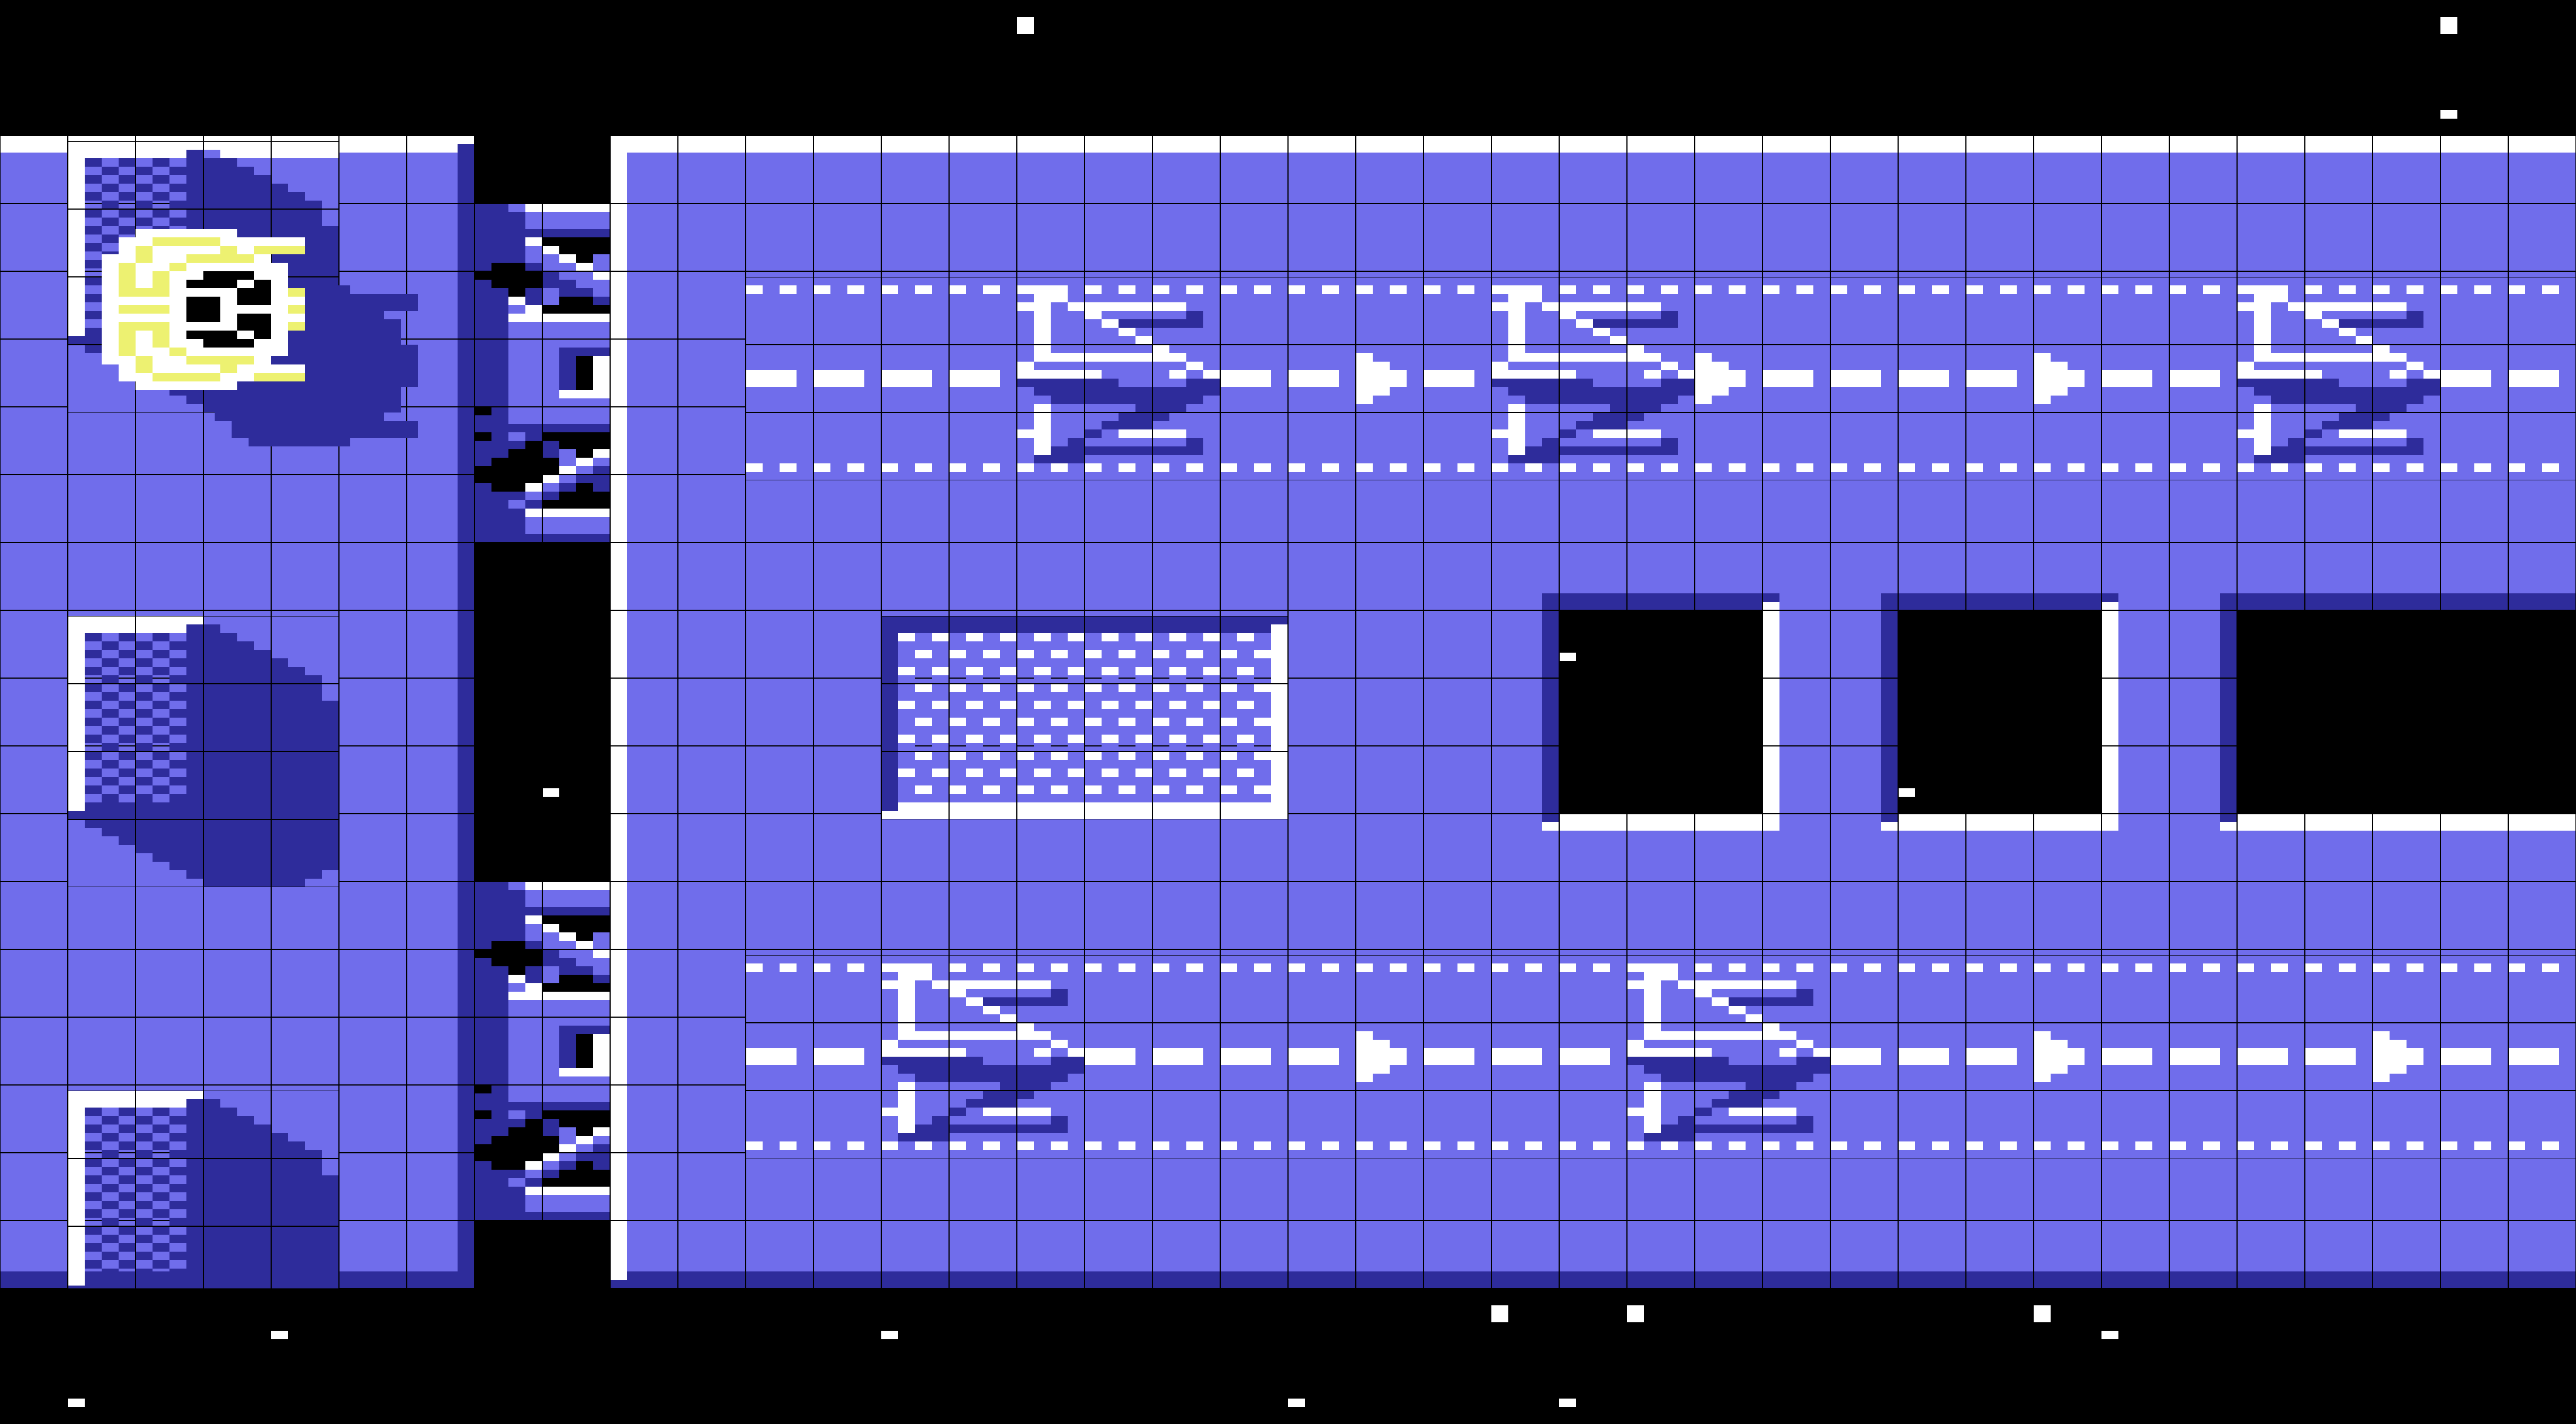

In [176]:
background = Image.new('RGBA', (cells(38), cells(21)), color="black")
for i in range(0,16):
    background = addRandomStar(background)

rows = [0,1,19,20]
for row in rows:
    background = addStarsToRow(background, row)

level = 14
diagram = get_surface_snippet(level=level, x_offset=cells(165), y_offset = cells(0), width=cells(38), height = cells(17))
shadow = make_shadow(manta.copy(), color=(0x2e,0x2c,0x9b,255))
manta_pos = (scale(12),scale(10))
shadow_offset = (20*10,10*10)
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.paste(manta, manta_pos, mask=manta)

background.paste(diagram, (0,cells(2)), mask=diagram)
background.save(f"starfield/dreadnought_with_stars_full.png")
background

## Scratchpad